In [1]:
import warnings 
warnings.filterwarnings("ignore")
from typing import Annotated,Literal,Sequence,TypedDict
from langchain import hub
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.pydantic_v1 import BaseModel,Field
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.tools.retriever import create_retriever_tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition,ToolNode
from langgraph.graph import END,StateGraph,START


/home/abhishek/daily/tasks/langchain/lang-env/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3579: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
import os

os.environ["LANGCHAIN_TRACING_V2"]='true'
os.environ["LANGCHAIN_ENDPOINT"]="https://api.smith.langchain.com"

In [3]:
import dotenv

dotenv.load_dotenv()

True

In [4]:
import ollama
ollama.pull("nomic-embed-text")

ProgressResponse(status='success', completed=None, total=None, digest=None)

In [5]:
from langchain_ollama import OllamaEmbeddings
embeddings=OllamaEmbeddings(model="nomic-embed-text")
from langchain_groq import ChatGroq
llm=ChatGroq(model="Gemma2-9b-It")

In [6]:
urls=[
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/'
]

In [7]:
docs=[WebBaseLoader(url).load() for url in urls]
docs_list=[item for sublist in docs for item in sublist]
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100,chunk_overlap=25)
doc_splits=text_splitter.split_documents(docs_list)

In [8]:
vectorstore=Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings
)

In [9]:
retriever=vectorstore.as_retriever()
retrieval_tool=create_retriever_tool(
    retriever,
    "retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents and prompt engineering")

In [10]:
from langchain_core.tools import tool
@tool
def off_topic():
    """Catch all Questions NOT related to Lilian  Weng blog posts on LLM agents and prompt engineering"""
    return "Forbidden - do not respond to the user"


tools = [retrieval_tool, off_topic]

In [11]:
class AgentState(TypedDict):
    messages: list
    force_answer: bool = False 

In [12]:
from langchain_core.messages import SystemMessage
def agent(state: AgentState):
    model = llm.bind_tools(tools)  # Proper tool binding
    response = model.invoke(state["messages"])
    return {"messages": state["messages"] + [response]}

def final_answer_agent(state: AgentState):
    # Use a different prompt/model for final answers
    response = llm.invoke([
        SystemMessage("ALWAYS answer the question directly"),
        *state["messages"]
    ])
    return {"messages": state["messages"] + [response]}

def should_continue(state) -> Literal["tools",END]:
    messages = state["messages"]
    last_message = messages[-1]
    if len(state["messages"]) > 6:  # Prevent infinite loops
        return "force_answer"
    if state["messages"][-1].content == "Forbidden - do not respond to the user":
        return "force_answer"
    if last_message.tool_calls:
        return "tools"
    return END

In [13]:
workflow = StateGraph(AgentState)

# Nodes
workflow.add_node("agent", agent)
workflow.add_node("tools", ToolNode(tools))
workflow.add_node("final_answer", final_answer_agent)

# Edges
workflow.add_edge(START, "agent")

# Conditional edges with proper mapping
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        "force_answer": "final_answer",
        END: END
    }
)

workflow.add_edge("tools", "agent")
workflow.add_edge("final_answer", END)  # Terminate after final answer

graph = workflow.compile()

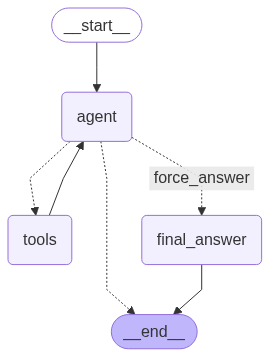

In [14]:
graph

In [15]:
response = graph.invoke({
    "messages": [HumanMessage("Is India in Asia?")],
    "force_answer": False
})

In [16]:
response

{'messages': [ToolMessage(content='Forbidden - do not respond to the user', name='off_topic', tool_call_id='373nxdrqx'),
  AIMessage(content='Forbidden - do not respond to the user', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 1073, 'total_tokens': 1083, 'completion_time': 0.018181818, 'prompt_time': 0.082488522, 'queue_time': 0.9381882699999999, 'total_time': 0.10067034}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--e6d7beb3-9309-493c-a4b1-54a5c2c47dbb-0', usage_metadata={'input_tokens': 1073, 'output_tokens': 10, 'total_tokens': 1083}),
  AIMessage(content='. \n\n', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 49, 'total_tokens': 55, 'completion_time': 0.010909091, 'prompt_time': 0.003798364, 'queue_time': 0.242768736, 'total_time': 0.014707455}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_

In [17]:
graph.invoke(
    input={"messages": [HumanMessage(content="where is delhi ?")]}
)

{'messages': [ToolMessage(content='Forbidden - do not respond to the user', name='off_topic', tool_call_id='qa4ajhr5y'),
  AIMessage(content='</tool-use>', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 1073, 'total_tokens': 1080, 'completion_time': 0.012727273, 'prompt_time': 0.046425689, 'queue_time': 0.24661346100000003, 'total_time': 0.059152962}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run--719fbad1-673f-4ecf-8c1b-6192b5f62614-0', usage_metadata={'input_tokens': 1073, 'output_tokens': 7, 'total_tokens': 1080})]}

In [ ]:
graph.invoke(
    input={"messages": [HumanMessage(content="what are lilian weng's blogpost about ?")]}
)

In [ ]:
graph.invoke(
    input={"messages": [HumanMessage(content="is india inside asia?")]}
)

{'messages': [HumanMessage(content='is india inside asia?', additional_kwargs={}, response_metadata={}, id='3bf0c8df-c623-45da-acfe-6a1c8ade45c8'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 't9qgvtzkm', 'function': {'arguments': '{}', 'name': 'off_topic'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 1051, 'total_tokens': 1123, 'completion_time': 0.130909091, 'prompt_time': 0.037176509, 'queue_time': 0.25425611099999995, 'total_time': 0.1680856}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--4497d887-fab2-47bc-b6a3-c931b9d530c2-0', tool_calls=[{'name': 'off_topic', 'args': {}, 'id': 't9qgvtzkm', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1051, 'output_tokens': 72, 'total_tokens': 1123}),
  ToolMessage(content='Forbidden - do not respond to the user', name='off_topic', id='3959317e-dc00-4b76-b69c-35eb7656790e', tool_c